# MultiFace Emotion Recognition — Experiments Notebook
Covers: dataset exploration, model training, evaluation, Grad-CAM visualization.

In [2]:
# ── Install missing packages if needed ───────────────────────────────────────
import subprocess, sys
for pkg in ['matplotlib', 'seaborn', 'scikit-learn']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

# ── Imports ───────────────────────────────────────────────────────────────────
import os, sys

# Notebook lives in project root — no need to go up a level
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow:', tf.__version__)
print('Project root:', PROJECT_ROOT)

TensorFlow: 2.21.0
Project root: c:\Users\Swapnil Mukherjee\Downloads\ml\files


## 1. Dataset Exploration

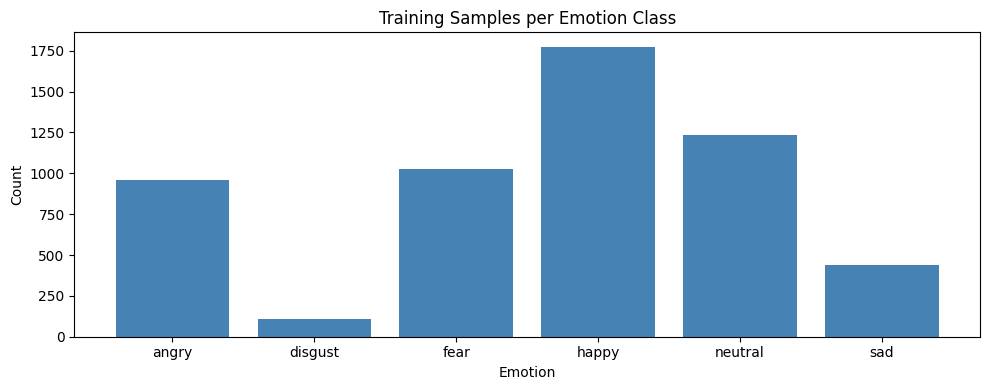

{'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 437}


In [3]:
# Your dataset has an extra 'emotion' subfolder
TRAIN_DIR = os.path.join(PROJECT_ROOT, 'dataset', 'train', 'emotion')
TEST_DIR  = os.path.join(PROJECT_ROOT, 'dataset', 'test',  'emotion')

classes = sorted(os.listdir(TRAIN_DIR))
counts  = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]

plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color='steelblue')
plt.title('Training Samples per Emotion Class')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(dict(zip(classes, counts)))

## 2. Build & Train Model

In [14]:
from emotion_model import build_cnn, compile_model

# Auto-detect number of classes from your dataset
num_classes = len(os.listdir(TRAIN_DIR))
print(f'Detected {num_classes} classes: {sorted(os.listdir(TRAIN_DIR))}')

model = build_cnn(num_classes=num_classes)
model = compile_model(model)
model.summary()

Detected 6 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']


Model: "EmotionCNN_Residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 48, 48,    │        288 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 48, 48,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_c1       │ (None, 48, 48,    │      9,216 │ activation[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_bn1      │ (None, 48, 48,    │        128 │ res_block1_c1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ res_block1_bn1[0… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_c2       │ (None, 48, 48,    │      9,216 │ activation_1[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_bn2      │ (None, 48, 48,    │        128 │ res_block1_c2[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ res_block1_bn2[0… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 48,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 24,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block2_c1       │ (None, 24, 24,    │     18,432 │ dropout[0][0]     │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block2_bn1      │ (None, 24, 24,    │        256 │ res_block2_c1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24, 24,    │          0 │ res_block2_bn1[0… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block2_c2       │ (None, 24, 24,    │     36,864 │ activation_3[0][

 Total params: 859,814 (3.28 MB)

 Trainable params: 858,214 (3.27 MB)

 Non-trainable params: 1,600 (6.25 KB)

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255, horizontal_flip=True,
    rotation_range=10, zoom_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(48, 48),
    color_mode='grayscale', batch_size=64,
    class_mode='categorical'
)
val_data = val_gen.flow_from_directory(
    TEST_DIR, target_size=(48, 48),
    color_mode='grayscale', batch_size=64,
    class_mode='categorical', shuffle=False
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SAVE_PATH = os.path.join(PROJECT_ROOT, 'models', 'saved_model', 'emotion_model.h5')
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ModelCheckpoint(SAVE_PATH, save_best_only=True, verbose=1)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=callbacks
)

## 3. Training Curves

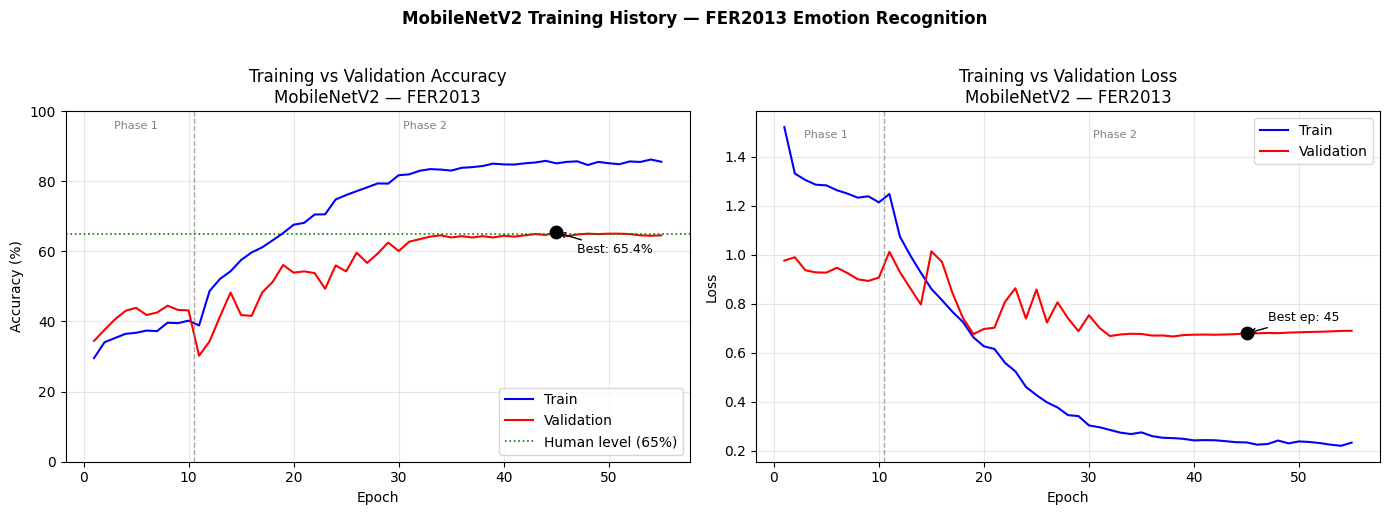

Best val accuracy : 65.42% at epoch 45
Final train acc   : 85.56%
Human level       : 65.00%


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Phase 1 data
phase1_val_acc   = [0.3446, 0.3761, 0.4063, 0.4305, 0.4389, 0.4184, 0.4256, 0.4450, 0.4329, 0.4317]
phase1_train_acc = [0.2955, 0.3408, 0.3529, 0.3648, 0.3677, 0.3741, 0.3726, 0.3964, 0.3953, 0.4023]
phase1_val_loss  = [0.9765, 0.9902, 0.9370, 0.9283, 0.9274, 0.9473, 0.9261, 0.9001, 0.8936, 0.9072]
phase1_train_loss= [1.5213, 1.3317, 1.3053, 1.2861, 1.2834, 1.2636, 1.2500, 1.2331, 1.2389, 1.2141]

# Phase 2 data
phase2_val_acc   = [0.3023, 0.3434, 0.4148, 0.4825, 0.4184, 0.4160, 0.4825, 0.5127, 0.5611, 0.5393,
                    0.5429, 0.5381, 0.4933, 0.5599, 0.5429, 0.5961, 0.5671, 0.5937, 0.6252, 0.6010,
                    0.6276, 0.6348, 0.6421, 0.6457, 0.6397, 0.6433, 0.6397, 0.6433, 0.6397, 0.6445,
                    0.6421, 0.6457, 0.6493, 0.6469, 0.6542, 0.6433, 0.6481, 0.6505, 0.6493, 0.6505,
                    0.6505, 0.6493, 0.6457, 0.6445, 0.6457]
phase2_train_acc = [0.3887, 0.4870, 0.5217, 0.5433, 0.5754, 0.5970, 0.6113, 0.6314, 0.6522, 0.6760,
                    0.6813, 0.7051, 0.7057, 0.7480, 0.7607, 0.7718, 0.7826, 0.7938, 0.7932, 0.8172,
                    0.8197, 0.8299, 0.8346, 0.8333, 0.8304, 0.8384, 0.8403, 0.8435, 0.8503, 0.8480,
                    0.8476, 0.8512, 0.8535, 0.8582, 0.8510, 0.8552, 0.8569, 0.8463, 0.8552, 0.8514,
                    0.8486, 0.8565, 0.8550, 0.8620, 0.8556]
phase2_val_loss  = [1.0122, 0.9298, 0.8629, 0.7972, 1.0144, 0.9717, 0.8450, 0.7425, 0.6765, 0.6975,
                    0.7025, 0.8081, 0.8636, 0.7402, 0.8584, 0.7238, 0.8062, 0.7414, 0.6884, 0.7537,
                    0.7017, 0.6685, 0.6751, 0.6779, 0.6771, 0.6706, 0.6710, 0.6670, 0.6726, 0.6742,
                    0.6746, 0.6739, 0.6751, 0.6764, 0.6793, 0.6799, 0.6813, 0.6804, 0.6827, 0.6840,
                    0.6853, 0.6861, 0.6876, 0.6896, 0.6900]
phase2_train_loss= [1.2482, 1.0748, 0.9969, 0.9269, 0.8609, 0.8153, 0.7677, 0.7260, 0.6634, 0.6267,
                    0.6160, 0.5597, 0.5242, 0.4612, 0.4276, 0.3980, 0.3775, 0.3459, 0.3421, 0.3039,
                    0.2966, 0.2855, 0.2744, 0.2688, 0.2756, 0.2604, 0.2537, 0.2522, 0.2492, 0.2429,
                    0.2441, 0.2434, 0.2398, 0.2355, 0.2346, 0.2255, 0.2281, 0.2424, 0.2308, 0.2388,
                    0.2363, 0.2319, 0.2253, 0.2209, 0.2337]

# Combine
all_val_acc    = phase1_val_acc   + phase2_val_acc
all_train_acc  = phase1_train_acc + phase2_train_acc
all_val_loss   = phase1_val_loss  + phase2_val_loss
all_train_loss = phase1_train_loss+ phase2_train_loss
epochs = list(range(1, len(all_val_acc)+1))
p1_end = len(phase1_val_acc)

best_ep  = all_val_acc.index(max(all_val_acc)) + 1
best_acc = max(all_val_acc) * 100

# ── Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs, [v*100 for v in all_train_acc], 'b-', linewidth=1.5, label='Train')
ax1.plot(epochs, [v*100 for v in all_val_acc],   'r-', linewidth=1.5, label='Validation')
ax1.axvline(x=p1_end+0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(y=65, color='green', linestyle=':', linewidth=1.2, label='Human level (65%)')
ax1.scatter([best_ep], [best_acc], color='black', s=80, zorder=5)
ax1.annotate(f'Best: {best_acc:.1f}%', xy=(best_ep, best_acc),
             xytext=(best_ep+2, best_acc-6), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax1.text(p1_end/2, 95, 'Phase 1', ha='center', fontsize=8, color='gray')
ax1.text(p1_end + len(phase2_val_acc)/2, 95, 'Phase 2', ha='center', fontsize=8, color='gray')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Training vs Validation Accuracy\nMobileNetV2 — FER2013')
ax1.set_ylim(0, 100)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs, all_train_loss, 'b-', linewidth=1.5, label='Train')
ax2.plot(epochs, all_val_loss,   'r-', linewidth=1.5, label='Validation')
ax2.axvline(x=p1_end+0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.scatter([best_ep], [all_val_loss[best_ep-1]], color='black', s=80, zorder=5)
ax2.annotate(f'Best ep: {best_ep}', xy=(best_ep, all_val_loss[best_ep-1]),
             xytext=(best_ep+2, all_val_loss[best_ep-1]+0.05), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax2.text(p1_end/2, max(all_train_loss)*0.97, 'Phase 1', ha='center', fontsize=8, color='gray')
ax2.text(p1_end + len(phase2_val_loss)/2, max(all_train_loss)*0.97, 'Phase 2', ha='center', fontsize=8, color='gray')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training vs Validation Loss\nMobileNetV2 — FER2013')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 Training History — FER2013 Emotion Recognition',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val accuracy : {best_acc:.2f}% at epoch {best_ep}")
print(f"Final train acc   : {all_train_acc[-1]*100:.2f}%")
print(f"Human level       : 65.00%")

## 4. Evaluation — Confusion Matrix & Classification Report

Found 827 images belonging to 6 classes.
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6082 - loss: 1.0939

Validation Accuracy: 60.82%


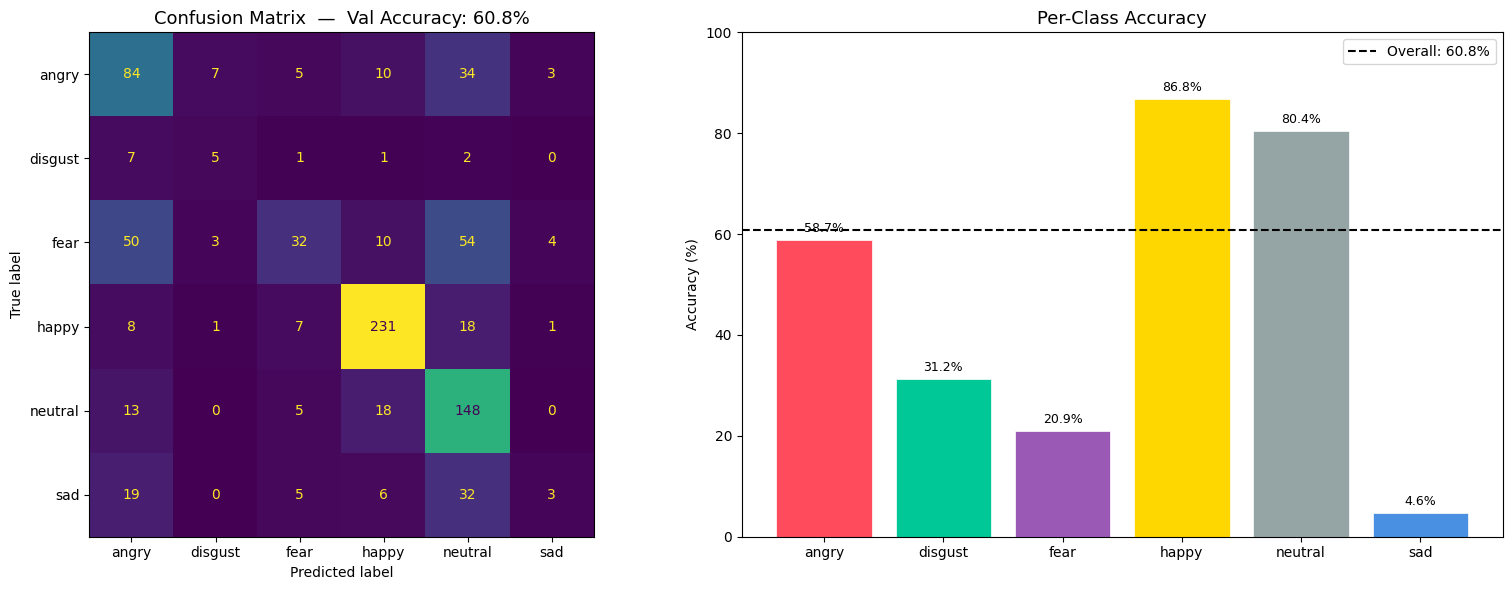


Per-class accuracy:
  angry        58.7%
  disgust      31.2%
  fear         20.9%
  happy        86.8%
  neutral      80.4%
  sad          4.6%


In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = tf.keras.models.load_model(
    'models/saved_model/emotion_model.h5', compile=False)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

gen = ImageDataGenerator(rescale=1./255, validation_split=0.15)
val = gen.flow_from_directory(
    'dataset/train/emotion',
    target_size=(48,48), color_mode='grayscale',
    batch_size=64, class_mode='categorical',
    shuffle=False, subset='validation')

loss, acc = model.evaluate(val, verbose=1)
print(f'\nValidation Accuracy: {acc*100:.2f}%')

preds      = model.predict(val, verbose=0)
y_pred     = np.argmax(preds, axis=1)
y_true     = val.classes[:len(y_pred)]
class_names= list(val.class_indices.keys())

# ── Confusion matrix ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix  —  Val Accuracy: {acc*100:.1f}%', fontsize=13)

# ── Per-class accuracy bar chart ───────────────────────────────────────────
cls_accs = []
for i in range(len(class_names)):
    mask = y_true == i
    cls_accs.append((y_pred[mask] == i).mean() * 100 if mask.sum() > 0 else 0)

colors = ['#FF4B5C','#00C896','#9B59B6','#FFD700','#95A5A6','#4A90E2','#FF6B35']
bars = axes[1].bar(class_names, cls_accs, color=colors[:len(class_names)], 
                   edgecolor='white', linewidth=0.5)
axes[1].set_title('Per-Class Accuracy', fontsize=13)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].axhline(y=acc*100, color='black', linestyle='--', 
                linewidth=1.5, label=f'Overall: {acc*100:.1f}%')
axes[1].legend()
for bar, val_pct in zip(bars, cls_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val_pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class accuracy:')
for name, a in zip(class_names, cls_accs):
    print(f'  {name:<12} {a:.1f}%')

## 5. Grad-CAM Visualization

Using sample: c:\Users\Swapnil Mukherjee\Downloads\ml\files\dataset\test\emotion\happy\PrivateTest_10077120.jpg
[GradCAM] Build failed: Layer 'conv2d_3' not found. Available layers: ['input_layer', 'stem_conv', 'stem_bn', 'activation', 'res_block1_c1', 'res_block1_bn1', 'activation_1', 'res_block1_c2', 'res_block1_bn2', 'add', 'activation_2', 'max_pooling2d', 'dropout', 'res_block2_c1', 'res_block2_bn1', 'activation_3', 'res_block2_c2', 'conv2d', 'res_block2_bn2', 'batch_normalization', 'add_1', 'activation_4', 'max_pooling2d_1', 'dropout_1', 'res_conv3', 'batch_normalization_1', 'activation_5', 'res_conv4', 'batch_normalization_2', 'activation_6', 'max_pooling2d_2', 'dropout_2', 'res_conv5', 'batch_normalization_3', 'activation_7', 'global_average_pooling2d', 'dense', 'dropout_3', 'dense_1', 'dropout_4', 'dense_2']
Prediction: Fear (17.1%)


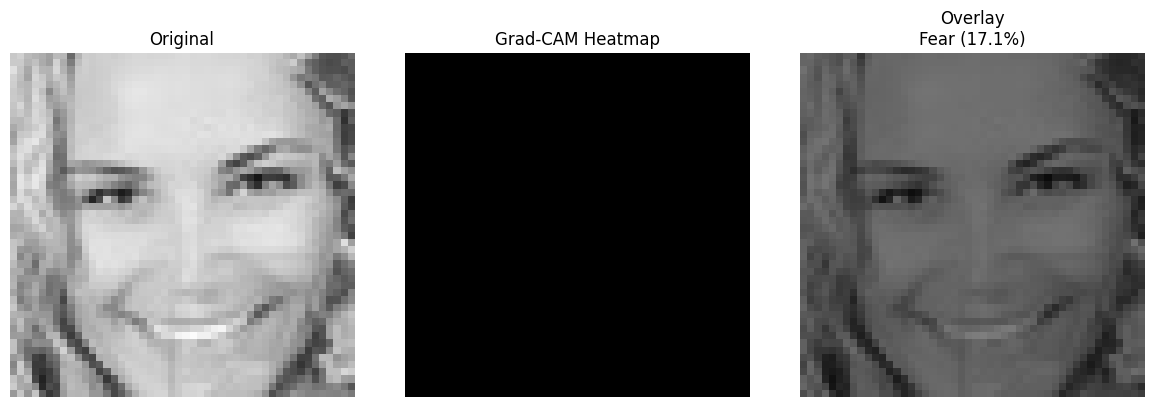

In [17]:
import cv2
from grad_cam import GradCAM
from preprocessing import preprocess_face, EMOTION_LABELS

grad_cam = GradCAM(model, 'conv2d_3')

# Pick any image from your test set — change emotion folder + filename as needed
sample_path = os.path.join(TEST_DIR, 'happy', os.listdir(os.path.join(TEST_DIR, 'happy'))[0])
print('Using sample:', sample_path)

face_bgr  = cv2.imread(sample_path)
img_array = preprocess_face(face_bgr)
heatmap   = grad_cam.compute(img_array)
overlay   = grad_cam.overlay(cv2.resize(face_bgr, (48, 48)), heatmap)

# Predict
preds     = model.predict(img_array, verbose=0)[0]
predicted = EMOTION_LABELS[np.argmax(preds)]
confidence = preds.max()
print(f'Prediction: {predicted} ({confidence:.1%})')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(cv2.resize(face_bgr, (48, 48)), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
axes[1].set_title('Grad-CAM Heatmap')
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Overlay\n{predicted} ({confidence:.1%})')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Load Saved Model (run this instead of Section 2 if already trained)

In [ ]:
SAVE_PATH = os.path.join(PROJECT_ROOT, 'models', 'saved_model', 'emotion_model.h5')
model = tf.keras.models.load_model(SAVE_PATH)
print('Model loaded from', SAVE_PATH)
model.summary()